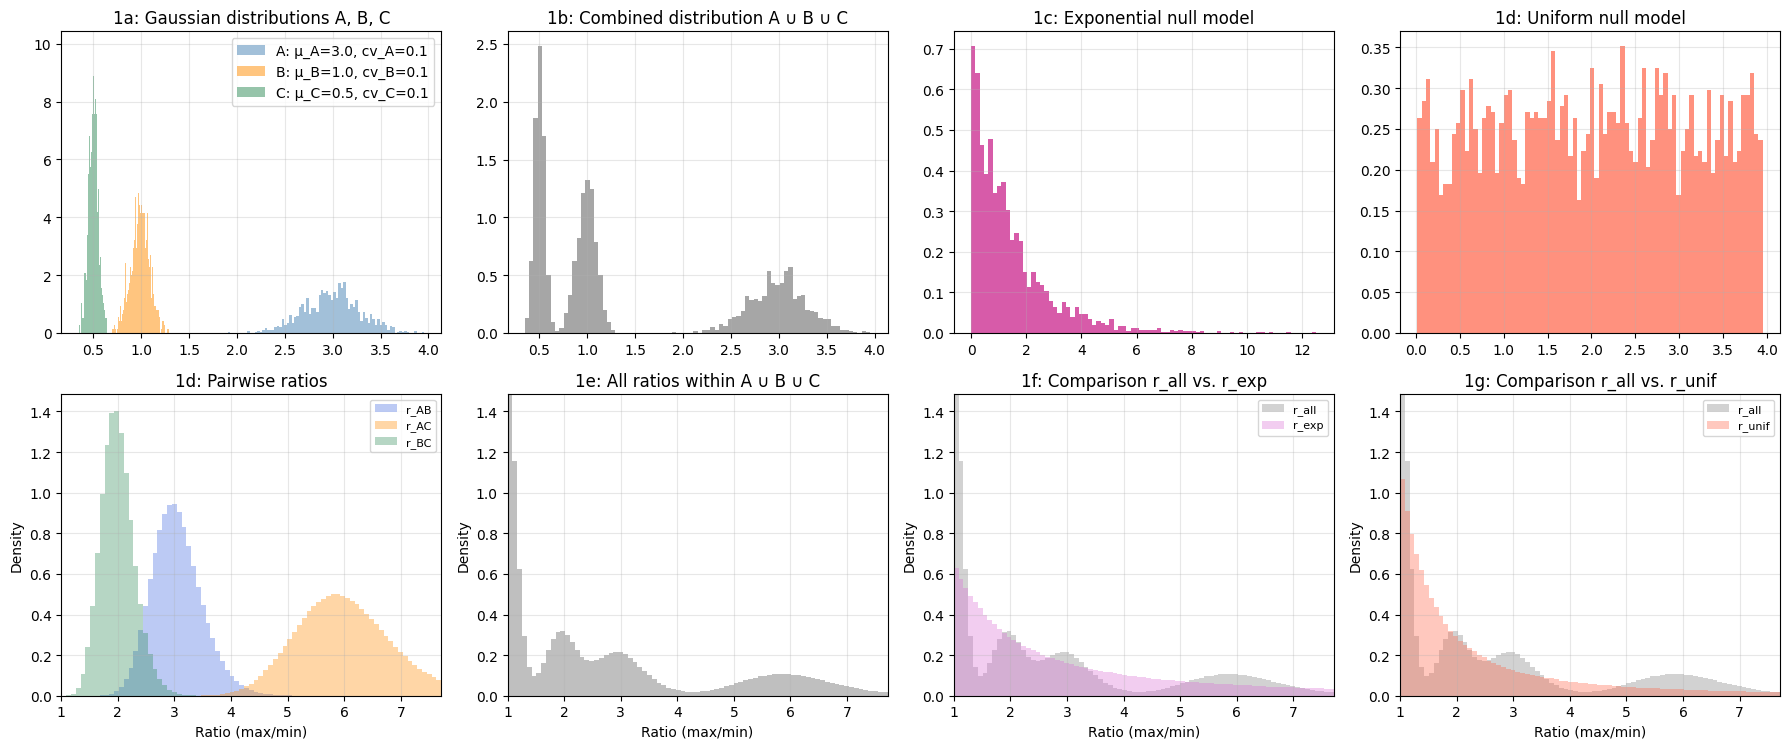

In [ ]:
# plot for introduction and simulation of IOI ratio distributions
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_ratio_panel_abc(
    sample_size=600,
    means=(30.2, 20.0, 10.0),
    cvs=(0.1, 0.13, 0.15),
    bins=80,
    random_seed=42,
    show_kde=True
):
    rng = np.random.default_rng(random_seed)

    # --- Drei Normalverteilungen ---
    stds = [m*c for m,c in zip(means, cvs)]
    A = rng.normal(means[0], stds[0], sample_size)
    B = rng.normal(means[1], stds[1], sample_size)
    C = rng.normal(means[2], stds[2], sample_size)

    all_values = np.concatenate([A, B, C])

    # Ratio-Funktion
    def ratio_pairs_unique(x, y):
        """Berechnet eindeutige Ratios (ohne Selbstvergleiche oder Dopplungen)."""
        x = np.asarray(x)
        y = np.asarray(y)
        if np.array_equal(x, y):
            # gleiche Liste → obere Dreiecksmatrix ohne Diagonale
            i_idx, j_idx = np.triu_indices(len(x), k=1)
            r = x[i_idx] / y[j_idx]
        else:
            # unterschiedliche Listen → alle Kombinationen
            r = x[:, None] / y[None, :]
            r = r.ravel()
        r = np.maximum(r, 1 / r)
        return r

    # --- Exponential Null-Modell ---
    mean_all = all_values.mean()
    E = rng.exponential(scale=mean_all, size=len(all_values))

    # --- Uniform Null-Modell (optional) ---
    #min_all = all_values.min()
    min_all = 0.01
    max_all = all_values.max()
    U = rng.uniform(low=min_all, high=max_all, size=len(all_values))

    # --- Ratios ---
    r_AB = ratio_pairs_unique(A, B)
    r_AC = ratio_pairs_unique(A, C)
    r_BC = ratio_pairs_unique(B, C)
    r_all = ratio_pairs_unique(all_values, all_values)
    r_exp = ratio_pairs_unique(E, E)
    r_unif = ratio_pairs_unique(U, U)  # optional

    # X-Achse für untere Reihe
    x_min = 1
    x_max = np.percentile(np.concatenate([r_AB, r_AC, r_BC, r_all]), 99)
    bins_lin = np.linspace(x_min, x_max, bins)

    fig, axs = plt.subplots(2, 4, figsize=(18,8))
    #fig.suptitle("Simulation of IOI Ratios - Panels 1a-h", fontsize=14, weight="bold")

    # --- Top row ---
    # 1a: Drei Gaussianen
    axs[0,0].hist(A, bins=bins, density=True, alpha=0.5, color="steelblue", label=f"A: µ_A={means[0]}, cv_A={cvs[0]}")
    axs[0,0].hist(B, bins=bins, density=True, alpha=0.5, color="darkorange", label=f"B: µ_B={means[1]}, cv_B={cvs[1]}")
    axs[0,0].hist(C, bins=bins, density=True, alpha=0.5, color="seagreen", label=f"C: µ_C={means[2]}, cv_C={cvs[2]}")
    axs[0,0].set_title("1a: Gaussian distributions A, B, C")
    axs[0,0].legend()
    axs[0,0].grid(alpha=0.3)

    # 1b: Kombinierte Verteilung
    axs[0,1].hist(all_values, bins=bins, density=True, alpha=0.7, color="gray")
    axs[0,1].set_title("1b: Combined distribution A ∪ B ∪ C")
    axs[0,1].grid(alpha=0.3)

    # 1c: Exponential
    axs[0,2].hist(E, bins=bins, density=True, alpha=0.7, color="mediumvioletred")
    axs[0,2].set_title("1c: Exponential null model")
    axs[0,2].grid(alpha=0.3)

    # 1d: Uniform (optional)
    axs[0,3].hist(U, bins=bins, density=True, alpha=0.7, color="tomato")
    axs[0,3].set_title("1d: Uniform null model")
    axs[0,3].grid(alpha=0.3)

    # --- Bottom row ---
    # 1e: Paarweise Ratios
    ax = axs[1,0]
    for r,color,label in zip([r_AB, r_AC, r_BC], ["royalblue","darkorange","seagreen"], ["r_AB","r_AC","r_BC"]):
        ax.hist(r, bins=bins_lin, density=True, alpha=0.35, color=color, label=label)
        if show_kde:
            kde = gaussian_kde(r)
            x_grid = np.linspace(x_min, x_max, 1000)
            ax.plot(x_grid, kde(x_grid), color=color, lw=2)
    ax.set_title("1e: Pairwise ratios")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # 1f: Alle-mit-allen Ratios
    ax = axs[1,1]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.5, color="gray")
    if show_kde:
        kde = gaussian_kde(r_all)
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde(x_grid), color="black", lw=2)
    ax.set_title("1f: All ratios within A ∪ B ∪ C")
    ax.grid(alpha=0.3)

    # 1g: Vergleich All vs. Exponential
    ax = axs[1,2]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_exp, bins=bins_lin, density=True, alpha=0.35, color="orchid", label="r_exp")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_exp = gaussian_kde(r_exp[r_exp<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_exp(x_grid), color="purple", lw=2, ls="--")
    ax.set_title("1g: Comparison r_all vs. r_exp")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # 1h: (optional) Vergleich All vs. Uniform
    ax = axs[1,3]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_unif, bins=bins_lin, density=True, alpha=0.35, color="tomato", label="r_unif")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_unif = gaussian_kde(r_unif[r_unif<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_unif(x_grid), color="green", lw=2, ls="--")
    ax.set_title("1h: Comparison r_all vs. r_unif")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # --- Gemeinsame X- und Y-Achsen für untere Reihe ---
    densities = []
    for r in [r_AB, r_AC, r_BC, r_all, r_exp]:
        kde = gaussian_kde(r[r<x_max])
        densities.append(kde(np.linspace(x_min,x_max,500)).max())
    y_max = max(densities)*1.05

    for ax in axs[1,:]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Ratio (max/min)")
        ax.set_ylabel("Density")

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Beispielaufruf
plot_ratio_panel_abc(
    sample_size=1000,
    means=(3.0, 1.0, 0.5),
    cvs=(0.1, 0.1, 0.1),
    random_seed=42,
    show_kde=False
)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_789/3844633396.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.95])
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_789/3844633396.py:205: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0,0,1,0.95])


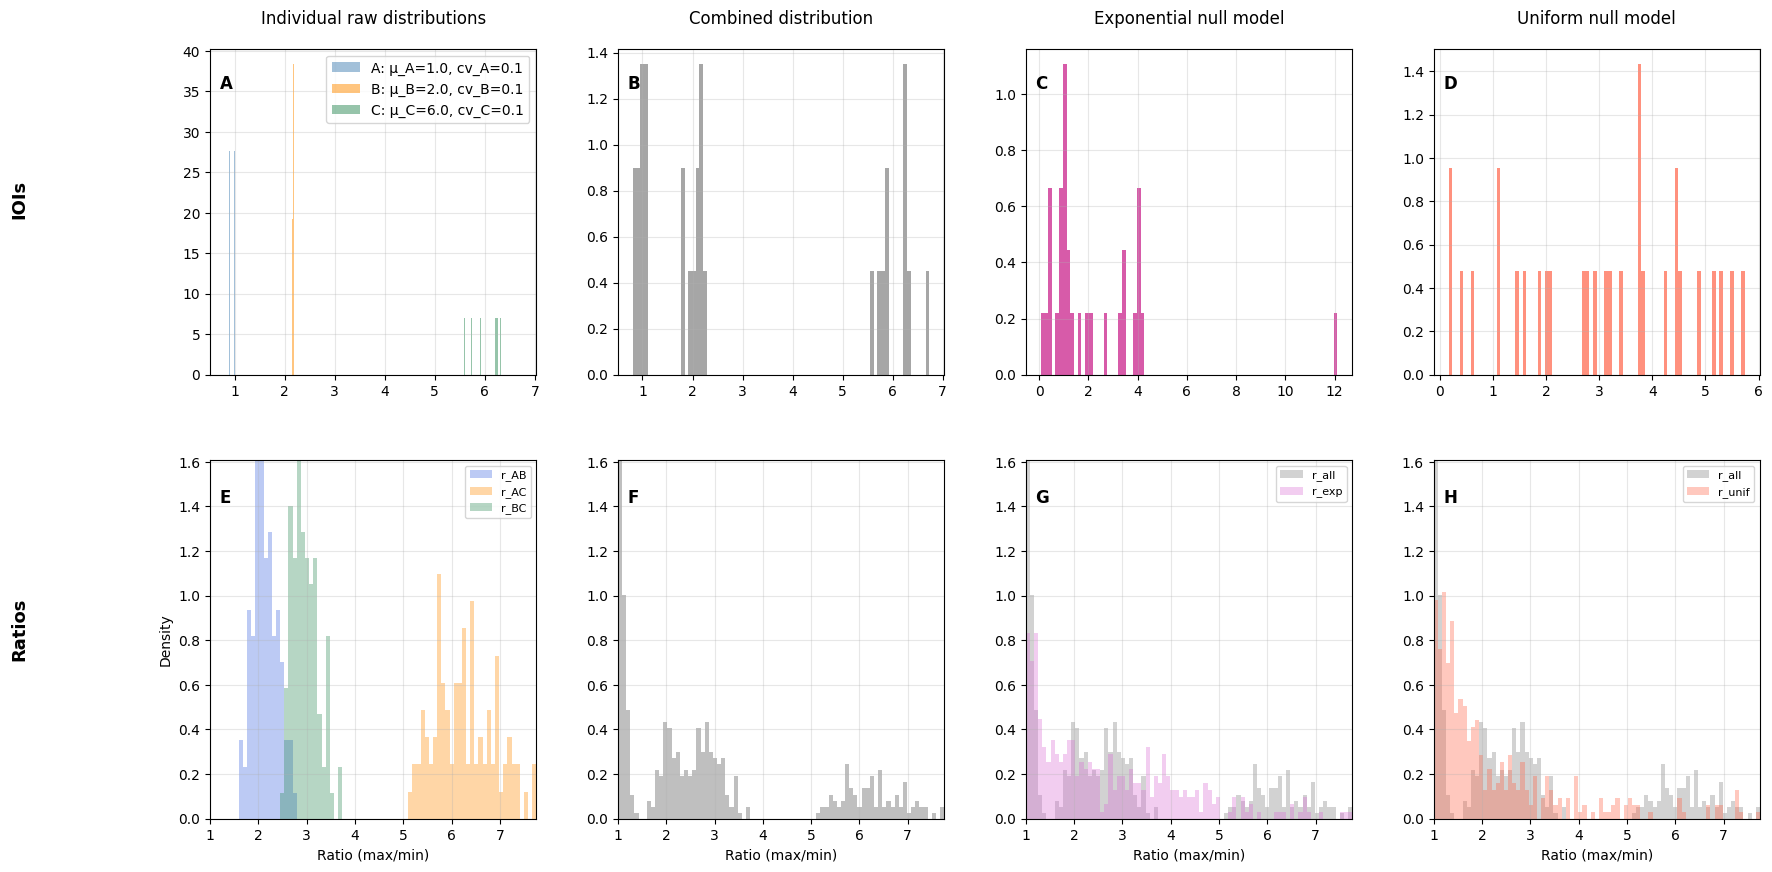

In [1]:
# plot for introduction and simulation of IOI ratio distributions
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
def add_panel_label(ax, label):
    ax.text(
        0.03, 0.92, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left"
    )

def plot_ratio_panel_abc(
    sample_size=600,
    means=(30.2, 20.0, 10.0),
    cvs=(0.1, 0.13, 0.15),
    bins=80,
    random_seed=42,
    show_kde=True
):
    rng = np.random.default_rng(random_seed)

    # --- Drei Normalverteilungen ---
    stds = [m*c for m,c in zip(means, cvs)]
    A = rng.normal(means[0], stds[0], sample_size)
    B = rng.normal(means[1], stds[1], sample_size)
    C = rng.normal(means[2], stds[2], sample_size)

    all_values = np.concatenate([A, B, C])

    # Ratio-Funktion
    def ratio_pairs_unique(x, y):
        """Berechnet eindeutige Ratios (ohne Selbstvergleiche oder Dopplungen)."""
        x = np.asarray(x)
        y = np.asarray(y)
        if np.array_equal(x, y):
            # gleiche Liste → obere Dreiecksmatrix ohne Diagonale
            i_idx, j_idx = np.triu_indices(len(x), k=1)
            r = x[i_idx] / y[j_idx]
        else:
            # unterschiedliche Listen → alle Kombinationen
            r = x[:, None] / y[None, :]
            r = r.ravel()
        r = np.maximum(r, 1 / r)
        return r

    # --- Exponential Null-Modell ---
    mean_all = all_values.mean()
    E = rng.exponential(scale=mean_all, size=len(all_values))

    # --- Uniform Null-Modell (optional) ---
    #min_all = all_values.min()
    min_all = 0.01
    max_all = all_values.max()
    U = rng.uniform(low=min_all, high=max_all, size=len(all_values))

    # --- Ratios ---
    r_AB = ratio_pairs_unique(A, B)
    r_AC = ratio_pairs_unique(A, C)
    r_BC = ratio_pairs_unique(B, C)
    r_all = ratio_pairs_unique(all_values, all_values)
    r_exp = ratio_pairs_unique(E, E)
    r_unif = ratio_pairs_unique(U, U)  # optional

    # X-Achse für untere Reihe
    x_min = 1
    x_max = np.percentile(np.concatenate([r_AB, r_AC, r_BC, r_all]), 99)
    bins_lin = np.linspace(x_min, x_max, bins)

    fig = plt.figure(figsize=(20, 10), constrained_layout=True)
    gs = fig.add_gridspec(
        2, 4,
        height_ratios=[1, 1.1],   # unten minimal höher (Ratios brauchen Platz)
        wspace=0.25,
        hspace=0.25
    )

    axs = np.array([
        [fig.add_subplot(gs[0, i]) for i in range(4)],
        [fig.add_subplot(gs[1, i]) for i in range(4)]
    ])

    column_titles = [
        "Individual raw distributions",
        "Combined distribution",
        "Exponential null model",
        "Uniform null model"
    ]

    for col, title in enumerate(column_titles):
        axs[0, col].set_title(title, fontsize=12, pad=18)

    fig.text(
        0.025, 0.73, "IOIs",
        rotation=90,
        fontsize=13,
        fontweight="bold",
        va="center"
    )

    fig.text(
        0.025, 0.30, "Ratios",
        rotation=90,
        fontsize=13,
        fontweight="bold",
        va="center"
    )

    # --- Top row ---
    # 1a: Drei Gaussianen
    axs[0,0].hist(A, bins=bins, density=True, alpha=0.5, color="steelblue", label=f"A: µ_A={means[0]}, cv_A={cvs[0]}")
    axs[0,0].hist(B, bins=bins, density=True, alpha=0.5, color="darkorange", label=f"B: µ_B={means[1]}, cv_B={cvs[1]}")
    axs[0,0].hist(C, bins=bins, density=True, alpha=0.5, color="seagreen", label=f"C: µ_C={means[2]}, cv_C={cvs[2]}")
    axs[0,0].legend()
    axs[0,0].grid(alpha=0.3)
    add_panel_label(axs[0,0], "A")

    # 1b: Kombinierte Verteilung
    axs[0,1].hist(all_values, bins=bins, density=True, alpha=0.7, color="gray")
    axs[0,1].grid(alpha=0.3)
    add_panel_label(axs[0,1], "B")

    # 1c: Exponential
    axs[0,2].hist(E, bins=bins, density=True, alpha=0.7, color="mediumvioletred")
    axs[0,2].grid(alpha=0.3)
    add_panel_label(axs[0,2], "C")

    # 1d: Uniform (optional)
    axs[0,3].hist(U, bins=bins, density=True, alpha=0.7, color="tomato")
    axs[0,3].grid(alpha=0.3)
    add_panel_label(axs[0,3], "D")

    # --- Bottom row ---
    # 1e: Paarweise Ratios
    ax = axs[1,0]
    for r,color,label in zip([r_AB, r_AC, r_BC], ["royalblue","darkorange","seagreen"], ["r_AB","r_AC","r_BC"]):
        ax.hist(r, bins=bins_lin, density=True, alpha=0.35, color=color, label=label)
        if show_kde:
            kde = gaussian_kde(r)
            x_grid = np.linspace(x_min, x_max, 1000)
            ax.plot(x_grid, kde(x_grid), color=color, lw=2)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    add_panel_label(axs[1,0], "E")

    # 1f: Alle-mit-allen Ratios
    ax = axs[1,1]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.5, color="gray")
    if show_kde:
        kde = gaussian_kde(r_all)
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde(x_grid), color="black", lw=2)
    ax.grid(alpha=0.3)
    add_panel_label(axs[1,1], "F")

    # 1g: Vergleich All vs. Exponential
    ax = axs[1,2]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_exp, bins=bins_lin, density=True, alpha=0.35, color="orchid", label="r_exp")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_exp = gaussian_kde(r_exp[r_exp<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_exp(x_grid), color="purple", lw=2, ls="--")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    add_panel_label(axs[1,2], "G")

    # 1h: (optional) Vergleich All vs. Uniform
    ax = axs[1,3]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_unif, bins=bins_lin, density=True, alpha=0.35, color="tomato", label="r_unif")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_unif = gaussian_kde(r_unif[r_unif<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_unif(x_grid), color="green", lw=2, ls="--")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    add_panel_label(axs[1,3], "H")

    # --- Gemeinsame X- und Y-Achsen für untere Reihe ---
    densities = []
    for r in [r_AB, r_AC, r_BC, r_all, r_exp]:
        kde = gaussian_kde(r[r<x_max])
        densities.append(kde(np.linspace(x_min,x_max,500)).max())
    y_max = max(densities)*1.05

    for ax in axs[1,:]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Ratio (max/min)")
        ax.set_ylabel("Density")

    for ax in axs[0, :]:
        ax.set_xlabel("")

    for ax in axs[:, 1:].flat:
        ax.set_ylabel("")

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Beispielaufruf
plot_ratio_panel_abc(
    sample_size=10,
    means=(1.0, 2.0, 6.0),
    cvs=(0.1, 0.1, 0.1),
    random_seed=42,
    show_kde=False
)


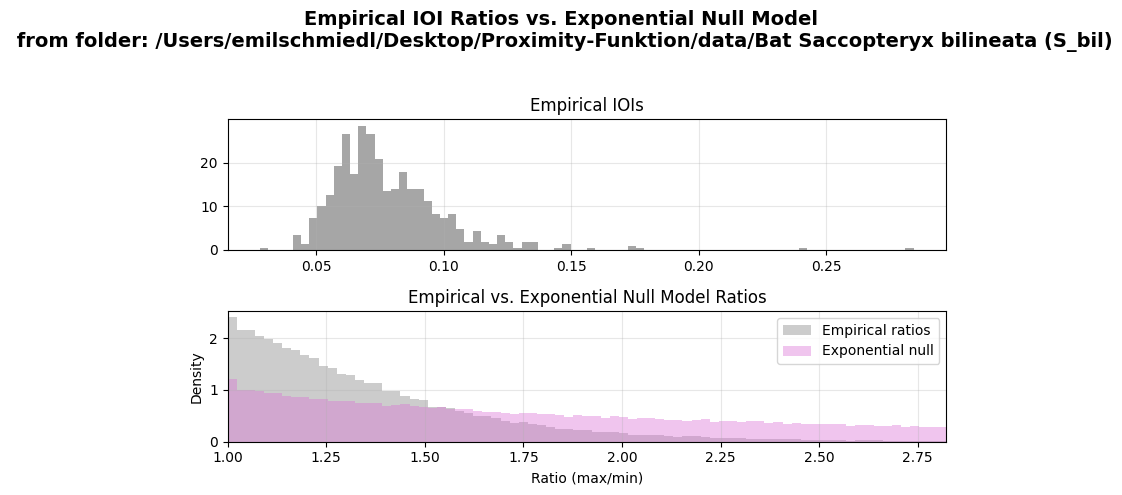

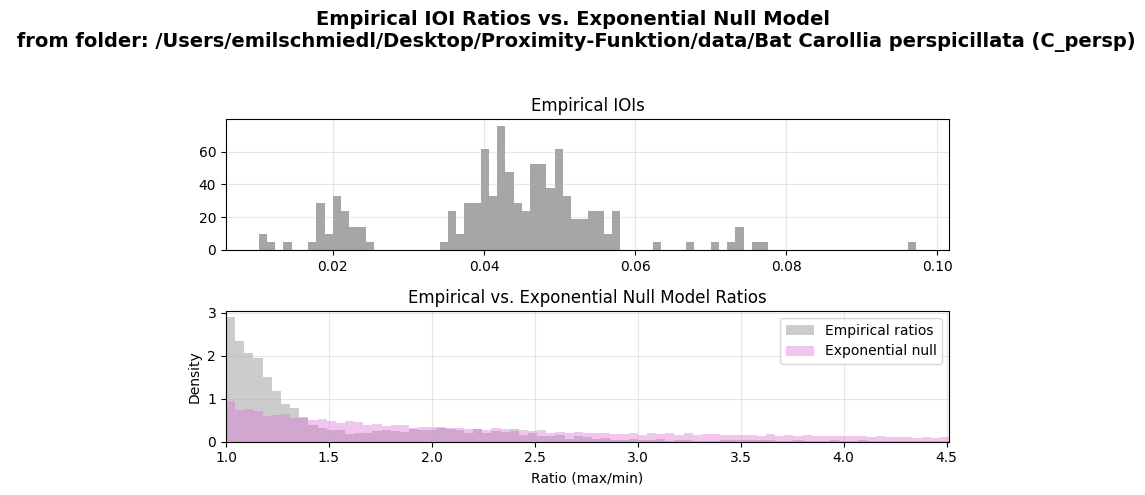

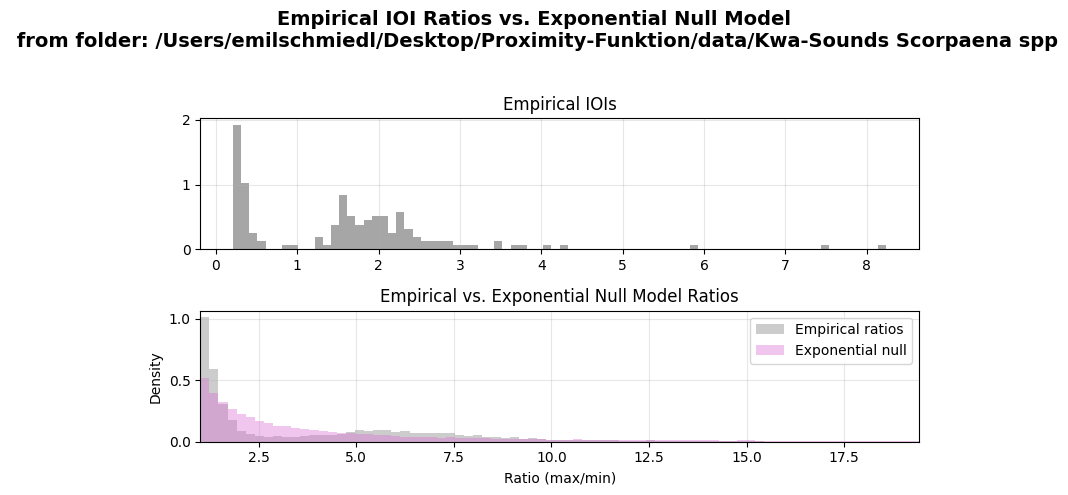

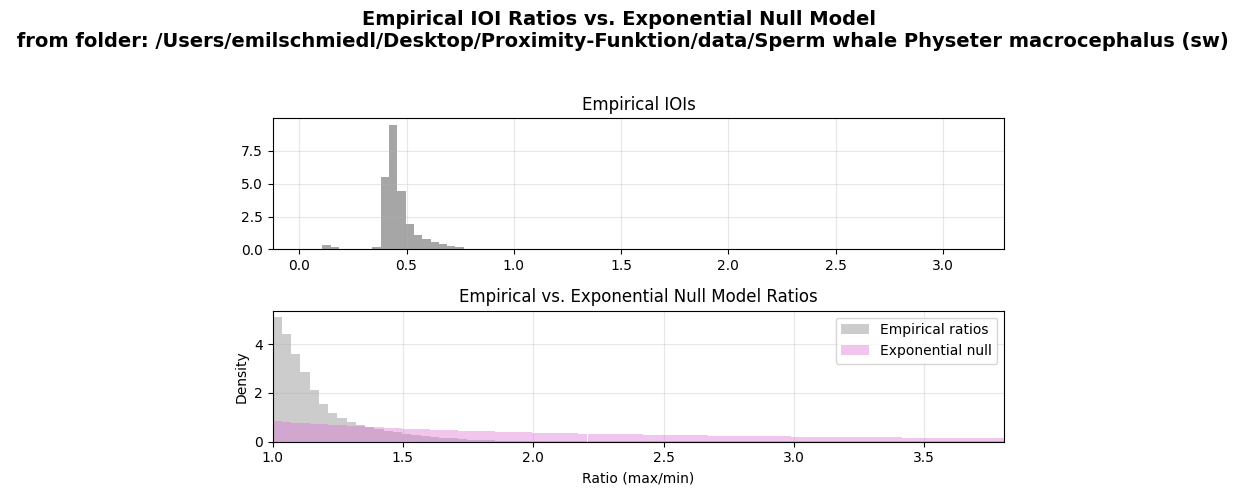

In [ ]:
# wie oben nur aus CSV-Dateien in einem Ordner
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import gaussian_kde

def plot_ratio_panel_from_folder(
    folder_path,
    bins=80,
    show_kde=True,
    random_seed=42
):
    """
    Reads all CSV files in a folder, extracts 'IOI' column values,
    and plots ratio distributions (empirical vs. exponential null model).
    """
    rng = np.random.default_rng(random_seed)

    # --- Alle CSV-Dateien im Ordner einlesen ---
    all_iois = []
    for file in os.listdir(folder_path):
        if file.lower().endswith(".csv"):
            path = os.path.join(folder_path, file)
            df = pd.read_csv(path)
            if "IOI" in df.columns:
                iois = df["IOI"].dropna().values
                all_iois.append(iois)
                #print(f"Loaded {len(iois)} IOIs from {file}")
            else:
                print(f"⚠️ Skipping {file}: no 'IOI' column found.")
    
    if not all_iois:
        raise ValueError("No valid CSV files with 'IOI' column found in folder.")

    # --- Kombinierte IOIs ---
    all_values = np.concatenate(all_iois)
    mean_all = np.mean(all_values)

    # --- Ratio-Funktion ---
    def ratio_pairs(x, y):
        r = (x[:, None] / y[None, :]).ravel()
        r = np.maximum(r, 1/r)
        return r

    # --- Ratios der kombinierten IOIs ---
    r_all = ratio_pairs(all_values, all_values)

    # --- Exponentielles Nullmodell ---
    E = rng.exponential(scale=mean_all, size=len(all_values))
    r_exp = ratio_pairs(E, E)

    # --- Plot-Setup ---
    x_min = 1
    x_max = np.percentile(r_all, 99)
    bins_lin = np.linspace(x_min, x_max, bins)

    fig, axs = plt.subplots(2, 1, figsize=(8, 5))
    fig.suptitle(f"Empirical IOI Ratios vs. Exponential Null Model\n from folder: {folder_path}", fontsize=14, weight="bold")

    # 1b: Kombinierte Verteilung
    ax = axs[0]
    ax.hist(all_values, bins=bins, density=True, alpha=0.7, color="gray")
    ax.set_title("Empirical IOIs")
    ax.grid(alpha=0.3)

    # --- Histogramme ---
    ax = axs[1]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.4, color="gray", label="Empirical ratios")
    ax.hist(r_exp, bins=bins_lin, density=True, alpha=0.4, color="orchid", label="Exponential null")
    ax.set_title("Empirical vs. Exponential Null Model Ratios")

    # --- KDEs ---
    if show_kde:
        kde_all = gaussian_kde(r_all[r_all < x_max])
        kde_exp = gaussian_kde(r_exp[r_exp < x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_exp(x_grid), color="purple", lw=2, ls="--")

    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Ratio (max/min)")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Beispielaufruf:
plot_ratio_panel_from_folder("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Bat Saccopteryx bilineata (S_bil)", show_kde=False)
plot_ratio_panel_from_folder("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp", show_kde=False)
plot_ratio_panel_from_folder("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)", show_kde=False)


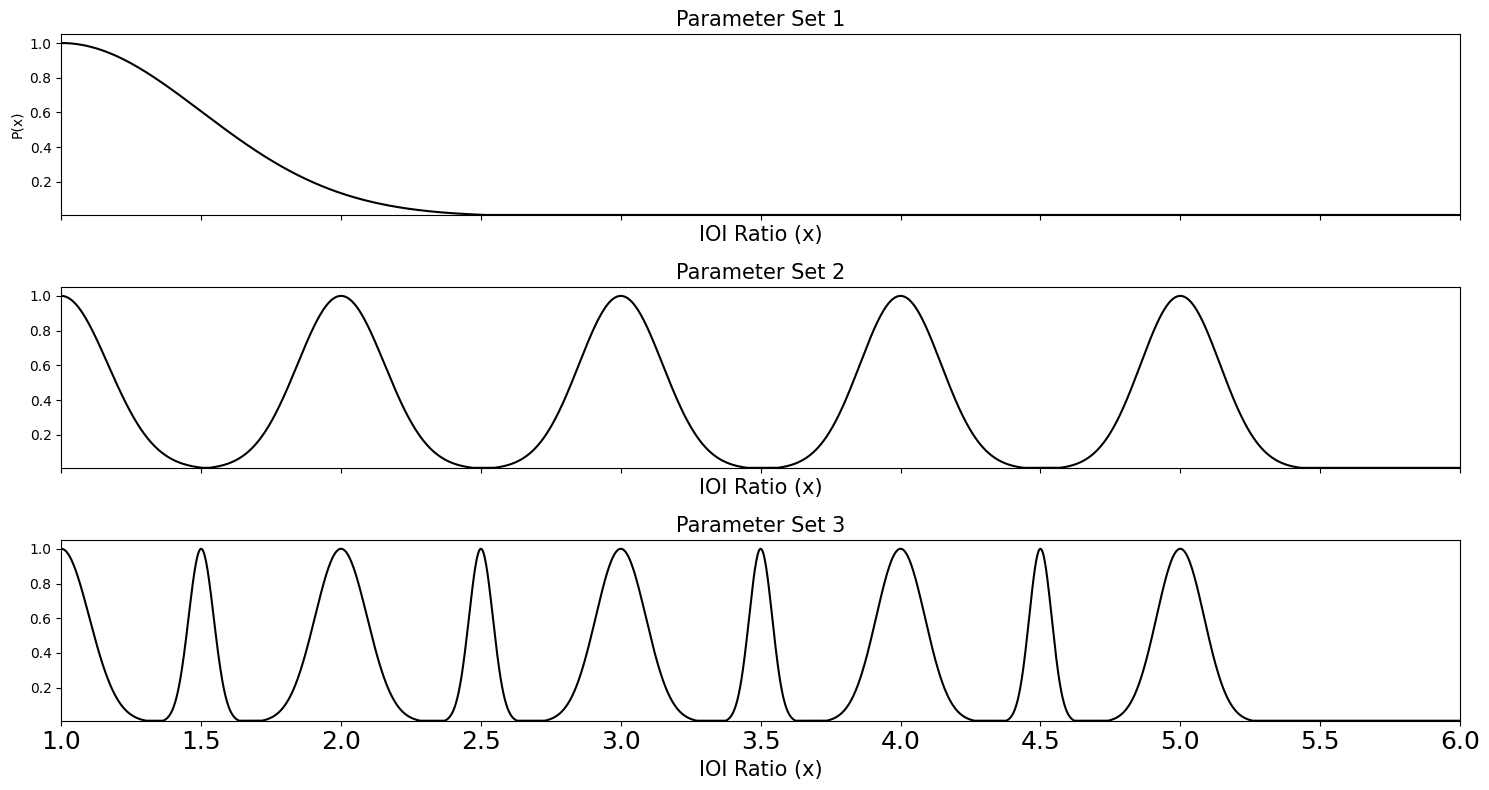

In [6]:
# plot for param-set study
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
importlib.reload(prox)

# =============================
# Compact overlay plot
# =============================
x = np.linspace(1, 6, 2000)

fig, axs = plt.subplots(3, 1, figsize=(15,8), sharex=True, sharey=True)
for idx, params in prox.param_sets.items():
    y, _ = prox.proximity_max_freq_gaussian_table(x, **params)
    axs[idx-1].plot(x, y, color="black", lw=1.5)
    axs[idx-1].set_title(f"Parameter Set {idx}", fontsize=15)
    axs[idx-1].set_xlabel("IOI Ratio (x)", fontsize=15)
    if idx == 1:
        axs[idx-1].set_ylabel("P(x)", fontsize=10)      
    axs[idx-1].set_xlim(x.min(), x.max())
    axs[idx-1].set_ylim(params["threshold"], 1.05)    
    axs[idx-1].set_xticks([1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6])
    plt.xticks(fontsize=18)

    plt.grid(False)
    plt.box(True)
            
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

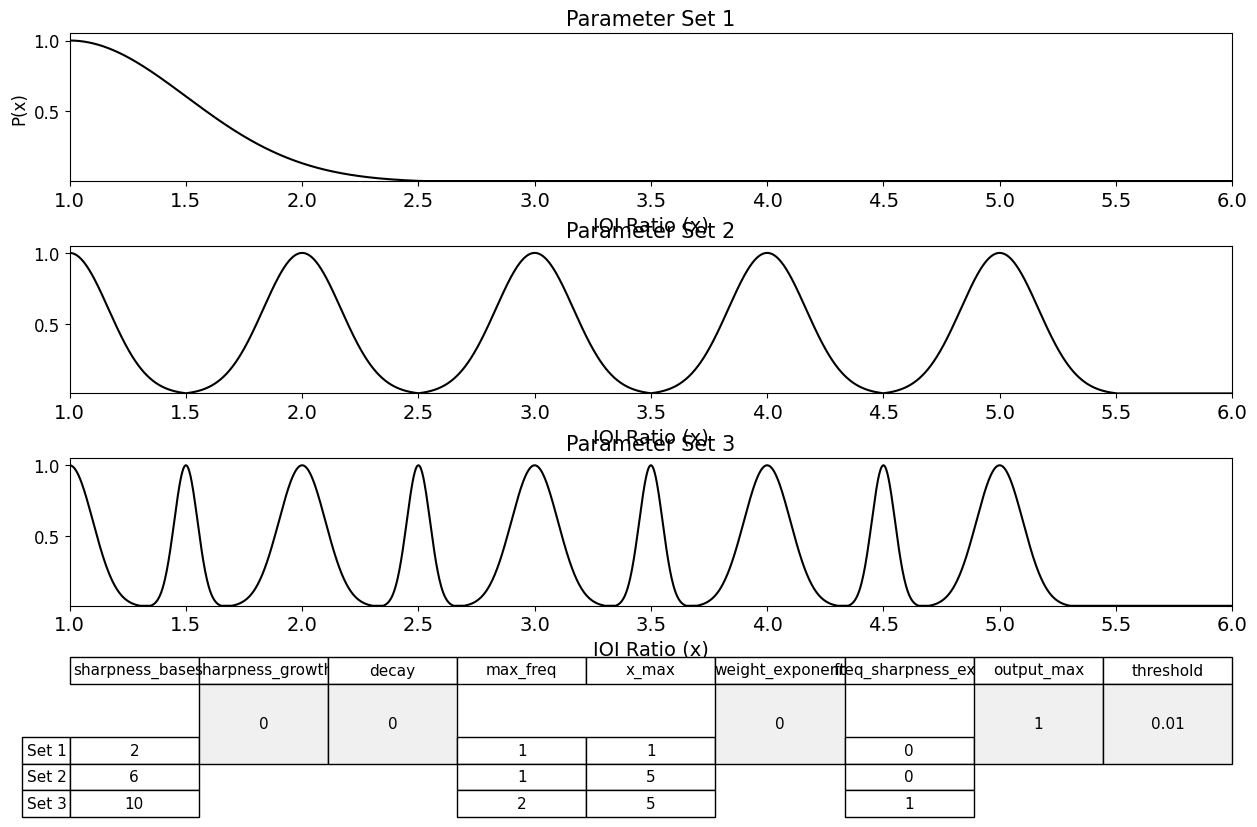

In [14]:
# plot for param-set study
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import importlib
import proximitylib.proximity as prox
importlib.reload(prox)

# =============================
# Compact overlay plot + table
# =============================
x = np.linspace(1, 6, 2000)

# ---- Figure layout: 3 plots + 1 table ----
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 0.9], hspace=0.45)

axs = [fig.add_subplot(gs[i, 0]) for i in range(3)]
ax_table = fig.add_subplot(gs[3, 0])
ax_table.axis("off")

# ---- Plots ----
for idx, params in prox.param_sets.items():
    y, _ = prox.proximity_max_freq_gaussian(x, **params)
    ax = axs[idx - 1]
    ax.plot(x, y, color="black", lw=1.5)
    ax.set_title(f"Parameter Set {idx}", fontsize=15)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(params["threshold"], 1.05)
    ax.set_xticks([1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6])
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=12)
    if idx == 1:
        ax.set_ylabel("P(x)", fontsize=12)
    ax.set_xlabel("IOI Ratio (x)", fontsize=14)
    for spine in ax.spines.values():
        spine.set_visible(True)


# ---- Build table data ----
param_sets = prox.param_sets
param_names = list(next(iter(param_sets.values())).keys())

# values per parameter
values = {p: [param_sets[i+1][p] for i in range(len(param_sets))] for p in param_names}

table_data = []
row_labels = [f"Set {i+1}" for i in range(len(param_sets))]

for row in range(len(param_sets)):
    row_vals = []
    for p in param_names:
        vals = values[p]
        # if identical across all sets → show only once
        if all(v == vals[0] for v in vals):
            row_vals.append(f"{vals[0]:.3g}" if row == 0 else "")
        else:
            v = vals[row]
            row_vals.append(f"{v:.3g}")
    table_data.append(row_vals)

# ---- Draw table ----
tbl = ax_table.table(
    cellText=table_data,
    colLabels=param_names,
    rowLabels=row_labels,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)

# ---- Fix row heights globally ----
n_sets = len(param_sets)

base_height = tbl[1, 0].get_height()

for row in range(1, n_sets + 1):
    for col in range(len(param_names)):
        tbl[row, col].set_height(base_height)


# ---- Merge shared parameters correctly ----
for col, p in enumerate(param_names):
    if all(v == values[p][0] for v in values[p]):

        # obere Zelle
        top_cell = tbl[1, col]
        top_cell.set_facecolor("#f0f0f0")
        top_cell.set_text_props(va="center", ha="center")
        top_cell.set_height(base_height * n_sets)

        # untere Zellen vollständig entfernen
        for row in range(2, n_sets + 1):
            cell = tbl[row, col]
            cell.visible_edges = ""
            cell.set_facecolor("none")
            cell.get_text().set_text("")

plt.show()


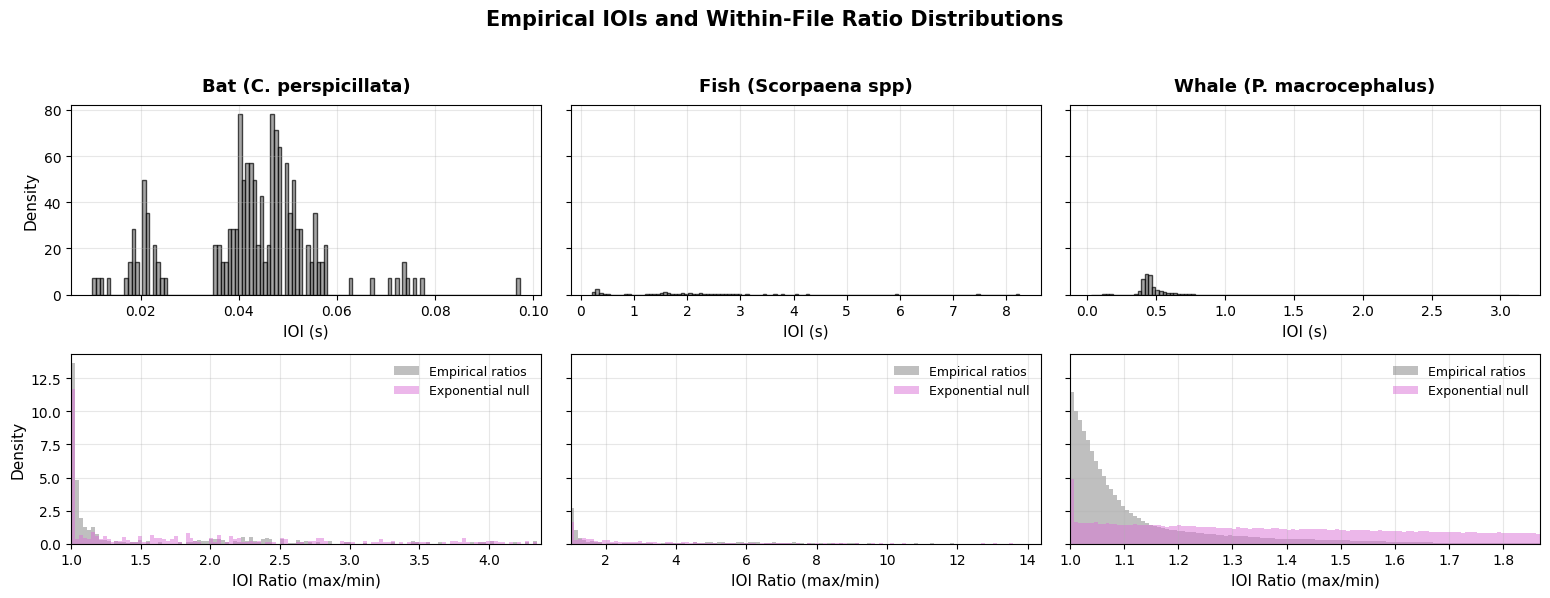

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


def plot_ratio_panel_for_folders(
    folder_dict,
    bins=80,
    random_seed=42,
    max_ratio_percentile=99,
):
    """
    Creates a 2xN panel (empirical IOIs and ratio distributions)
    for multiple datasets (folders). Ratios are computed *within*
    each CSV file, never across files.

    Parameters
    ----------
    folder_dict : dict
        {"Label": "/path/to/folder", ...}
    bins : int
        Number of histogram bins.
    random_seed : int
        RNG seed for reproducibility.
    max_ratio_percentile : float
        Upper percentile cutoff for ratio outliers.
    """
    rng = np.random.default_rng(random_seed)
    n = len(folder_dict)
    fig, axs = plt.subplots(2, n, figsize=(5.2 * n, 6), sharey='row')

    for idx, (label, folder_path) in enumerate(folder_dict.items()):
        all_iois = []
        all_ratios = []
        all_ratios_exp = []

        # --- Alle CSVs im Ordner einlesen ---
        for file in os.listdir(folder_path):
            if not file.lower().endswith(".csv"):
                continue
            path = os.path.join(folder_path, file)
            df = pd.read_csv(path)
            if "IOI" not in df.columns:
                continue
            iois = df["IOI"].dropna().values
            if len(iois) < 2:
                continue
            all_iois.append(iois)

            # Ratios innerhalb der Datei
            r = (iois[:, None] / iois[None, :]).ravel()
            r = np.maximum(r, 1 / r)
            r = r[r < np.percentile(r, max_ratio_percentile)]
            all_ratios.append(r)

            # Nullmodell (Exponential)
            mean_ioi = np.mean(iois)
            E = rng.exponential(scale=mean_ioi, size=len(iois))
            r_exp = (E[:, None] / E[None, :]).ravel()
            r_exp = np.maximum(r_exp, 1 / r_exp)
            r_exp = r_exp[r_exp < np.percentile(r_exp, max_ratio_percentile)]
            all_ratios_exp.append(r_exp)

        if not all_iois:
            print(f"⚠️ No valid data in {folder_path}")
            continue

        iois_all = np.concatenate(all_iois)
        ratios_all = np.concatenate(all_ratios)
        ratios_exp_all = np.concatenate(all_ratios_exp)

        # --- Achsen ---
        x_min = 1
        x_max = np.percentile(ratios_all, max_ratio_percentile)
        bins_lin = np.linspace(x_min, x_max, bins)

        # === Obere Zeile: IOI-Verteilung ===
        ax1 = axs[0, idx]
        ax1.hist(iois_all, bins=bins, density=True, alpha=0.7, color="gray", edgecolor="black")
        ax1.set_title(label, fontsize=13, weight="bold", pad=10)
        if idx == 0:
            ax1.set_ylabel("Density", fontsize=11)
        ax1.set_xlabel("IOI (s)", fontsize=11)
        ax1.grid(alpha=0.3)

        # === Untere Zeile: Ratio-Verteilung ===
        ax2 = axs[1, idx]
        ax2.hist(ratios_all, bins=bins_lin, density=True, alpha=0.5, color="gray", label="Empirical ratios")
        ax2.hist(ratios_exp_all, bins=bins_lin, density=True, alpha=0.5, color="orchid", label="Exponential null")
        ax2.set_xlim(x_min, x_max)
        if idx == 0:
            ax2.set_ylabel("Density", fontsize=11)
        ax2.set_xlabel("IOI Ratio (max/min)", fontsize=11)
        ax2.grid(alpha=0.3)
        ax2.legend(fontsize=9, frameon=False, loc="upper right")

    fig.suptitle("Empirical IOIs and Within-File Ratio Distributions", fontsize=15, weight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# === Beispielaufruf ===
plot_ratio_panel_for_folders(
    {
        "Bat (C. perspicillata)": "../data/Bat Carollia perspicillata (C_persp)",
        "Fish (Scorpaena spp)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp",
        "Whale (P. macrocephalus)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)",
    },
    bins=120,
)


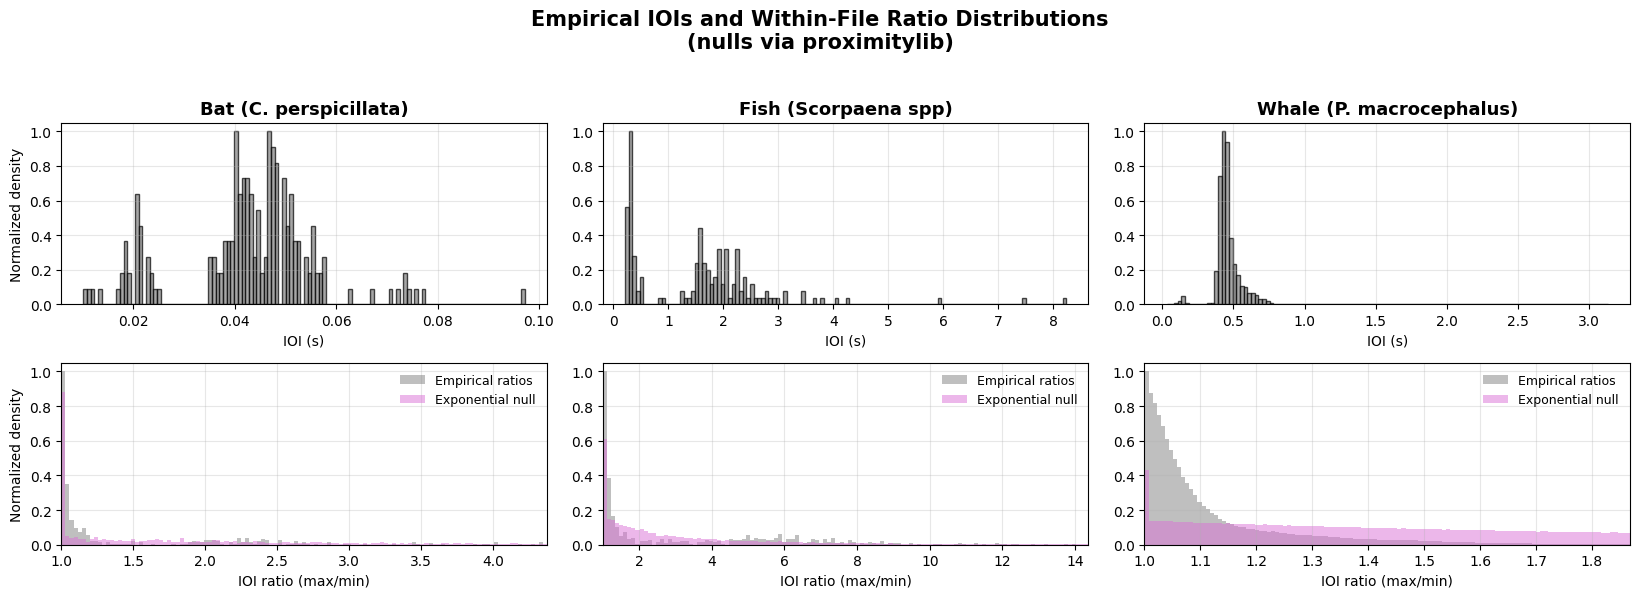

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import sys

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)

def plot_ratio_panel_from_folders_with_nulls(
    folder_dict,
    bins=100,
    num_null_sequences=100,
    random_seed=42,
    max_ratio_percentile=99,
    use_proximity_weight=False,
    param_choice=1,
):
    """
    Creates a 2×N panel (empirical IOIs + ratio distributions) for multiple datasets.
    Null models are generated via prox.generate_null_sequences().
    Ratios are computed within files, and distributions normalized per dataset.

    Parameters
    ----------
    folder_dict : dict
        {"Label": "/path/to/folder", ...}
    bins : int
        Histogram bins.
    num_null_sequences : int
        Number of exponential null sequences per file.
    random_seed : int
        RNG seed.
    max_ratio_percentile : float
        Percentile cutoff for extreme ratios.
    use_proximity_weight : bool
        If True, apply proximity_max_freq_gaussian_table() as weighting to ratios.
    param_choice : int
        Parameter set for proximity weighting (if used).
    """

    rng = np.random.default_rng(random_seed)
    n = len(folder_dict)
    params = prox.param_sets[param_choice]

    fig, axs = plt.subplots(2, n, figsize=(5.5 * n, 6), sharey=False)

    for idx, (label, folder_path) in enumerate(folder_dict.items()):
        all_iois, all_ratios, all_ratios_null = [], [], []

        for file in os.listdir(folder_path):
            if not file.lower().endswith(".csv"):
                continue
            df = pd.read_csv(os.path.join(folder_path, file))
            if "IOI" not in df.columns:
                continue
            iois = df["IOI"].dropna().values
            if len(iois) < 2:
                continue

            # --- Real ratios ---
            r = (iois[:, None] / iois[None, :]).ravel()
            r = np.maximum(r, 1 / r)
            r = r[r < np.percentile(r, max_ratio_percentile)]
            all_ratios.append(r)
            all_iois.append(iois)

            # --- Null sequences über prox.generate_null_sequences() ---
            nulls = prox.generate_null_sequences(iois, num_sequences=num_null_sequences, models=("expon",), seed=random_seed)
            null_iois = nulls["expon"]

            null_ratios_list = []
            for sim_iois in null_iois:
                rr = (sim_iois[:, None] / sim_iois[None, :]).ravel()
                rr = np.maximum(rr, 1 / rr)
                rr = rr[rr < np.percentile(rr, max_ratio_percentile)]
                if use_proximity_weight:
                    # apply proximity weighting (optional, more biologically meaningful)
                    weights, _ = prox.proximity_max_freq_gaussian_table(rr, **params)
                    rr = np.repeat(rr, np.clip((weights * 10).astype(int), 1, None))  # weight ratios
                null_ratios_list.append(rr)

            all_ratios_null.append(np.concatenate(null_ratios_list))

        if not all_iois:
            print(f"⚠️ No valid IOI data in {folder_path}")
            continue

        iois_all = np.concatenate(all_iois)
        ratios_all = np.concatenate(all_ratios)
        ratios_null_all = np.concatenate(all_ratios_null)

        # --- Histogram-Bereiche ---
        x_min = 1
        x_max = np.percentile(ratios_all, max_ratio_percentile)
        bins_lin = np.linspace(x_min, x_max, bins)

        # === Oberes Panel: IOI ===
        ax1 = axs[0, idx]
        h_ioi, e_ioi = np.histogram(iois_all, bins=bins, density=True)
        ax1.bar((e_ioi[:-1] + e_ioi[1:]) / 2, h_ioi / h_ioi.max(), width=np.diff(e_ioi),
                color="gray", alpha=0.7, edgecolor="black")
        ax1.set_title(label, fontsize=13, weight="bold")
        ax1.set_xlabel("IOI (s)")
        if idx == 0:
            ax1.set_ylabel("Normalized density")
        ax1.grid(alpha=0.3)

        # === Unteres Panel: Ratios ===
        ax2 = axs[1, idx]
        h_emp, e_emp = np.histogram(ratios_all, bins=bins_lin, density=True)
        h_null, _ = np.histogram(ratios_null_all, bins=bins_lin, density=True)

        scale = max(h_emp.max(), h_null.max())
        h_emp /= scale
        h_null /= scale

        ax2.bar((e_emp[:-1] + e_emp[1:]) / 2, h_emp, width=np.diff(e_emp),
                alpha=0.5, color="gray", label="Empirical ratios", edgecolor="none")
        ax2.bar((e_emp[:-1] + e_emp[1:]) / 2, h_null, width=np.diff(e_emp),
                alpha=0.5, color="orchid", label="Exponential null", edgecolor="none")

        ax2.set_xlim(x_min, x_max)
        ax2.set_xlabel("IOI ratio (max/min)")
        if idx == 0:
            ax2.set_ylabel("Normalized density")
        ax2.grid(alpha=0.3)
        ax2.legend(fontsize=9, frameon=False, loc="upper right")

    fig.suptitle("Empirical IOIs and Within-File Ratio Distributions\n(nulls via proximitylib)", fontsize=15, weight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# === Beispielaufruf ===
plot_ratio_panel_from_folders_with_nulls(
    {
        "Bat (C. perspicillata)": "../data/Bat Carollia perspicillata (C_persp)",
        "Fish (Scorpaena spp)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp",
        "Whale (P. macrocephalus)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)",
    },
    bins=120,
    num_null_sequences=200,
    use_proximity_weight=False,  # True = gewichtet nach deiner Proximity-Kurve
)


In [ ]:
# matrix panels for multiple files
from pathlib import Path
import sys

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))  # geht eine Ebene hoch

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from fractions import Fraction
from proximitylib.proximity import build_pairwise_proximity_df, proximity_max_freq_gaussian, param_sets
import math

def panel_peak_matrices_3rows(file_paths, param_choice=0, figsize=(20, 20), save_path=None):
    """
    Panel mit Peakvalue-Matrizen für mehrere Dateien in 3 Reihen.

    Parameters
    ----------
    file_paths : list of str | Path
        Liste von vollständigen Pfaden zu CSV-Dateien mit 'IOI'-Spalte.
    param_choice : int | str
        Param-Dict aus param_sets.
    figsize : tuple
        Figurgröße.
    save_path : str | Path | None
        Optionaler Speicherort.
    """
    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 3)
    n_rows = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()

    params = param_sets[param_choice]

    # Farben für Peak-Labels (Basisfarben)
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }

    # -------------------------
    # Alle Peak-Labels über alle Dateien sammeln (nur tatsächlich genutzte Labels)
    # -------------------------
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        # explizit als string, NaN/None ausschließen
        labels_here = pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
        # evtl. leere Strings entfernen
        labels_here = [lab for lab in labels_here if lab != "" and lab.lower() != "nan"]
        all_peak_labels.update(labels_here)
    all_peak_labels = sorted(all_peak_labels)

    # Falls du möchtest, dass "Keine Proximity" immer dabei ist, sicherstellen:
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")
    
    # Farben zuordnen
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1,1,1)  # weiß
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            color = plt.cm.tab20(idx % 20)
            label_to_color[lab] = color

    # Dateien plotten
    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            color = (*base_color[:3], alpha)
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='none'))
            if n <= 2 and not np.isnan(val):
                ax.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')

        if len(iois) <= 10:
            ax.set_xticks(np.arange(n) + 0.5)
            ax.set_yticks(np.arange(n) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1))
            ax.set_yticklabels(np.arange(1, n+1))
        elif len(iois) <= 30:
            step = 3
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))
        else: 
            step = 10
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))

        ax.set_title(Path(path).stem, fontsize=10, fontweight='bold')

    # Gemeinsame Legende (nur für die tatsächlich verwendeten Labels)
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=label_to_color[lab], edgecolor='black')
               for lab in all_peak_labels]
    labels = all_peak_labels  # in gleicher Reihenfolge
    fig.subplots_adjust(bottom=0.1, hspace=0.3)
    fig.legend(handles, labels, loc='lower center', ncol=min(len(labels), 10),
               fontsize=10, title="Peak-Labels", frameon=False)

    # Achsen für leere Plätze deaktivieren
    for ax in axes[n_files:]:
        ax.axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel gespeichert unter: {save_path}")

    plt.show()

files = [
    "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-1-2_jitter-0050/heterochrony-1-2_jitter-0050_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0001/isochrony_jitter-0001_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential/random_exponential_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift/isochrony_drift.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050/jitter_middle-0050_02.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0050/heterochrony-2-3_jitter-0050_06.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0050/isochrony_jitter-0050_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_uniform/random_uniform_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/accelerando/accelerando.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050/tempo_shift_onlyioi-jitter-0050_06.csv"
]

animals = [
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p4_b4.csv",
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p4_b9.csv",
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p2_b7.csv",
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p3_b2.csv",
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p1_b3.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA2-C.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA4.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA6.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA8.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA10.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_02.xls.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_10.xls.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_32.xls.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_51.xls.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_55.xls.csv"
]

panel_peak_matrices_3rows(animals, param_choice=3, figsize=(18, 10), save_path="animals_panel.png")

KeyboardInterrupt: 

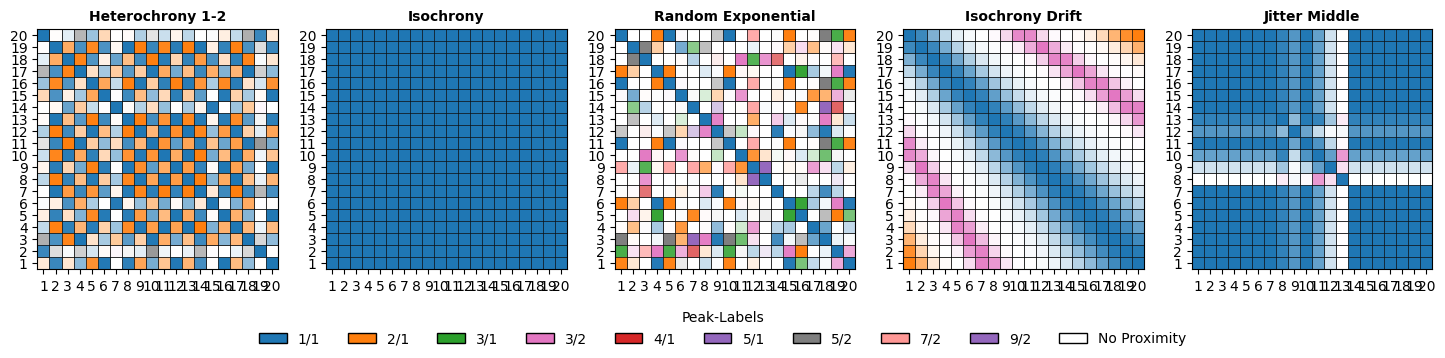

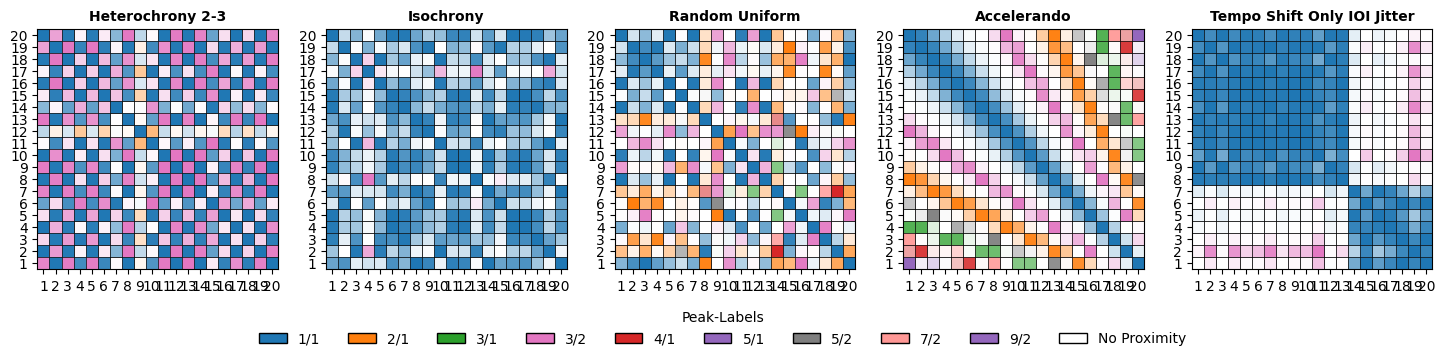

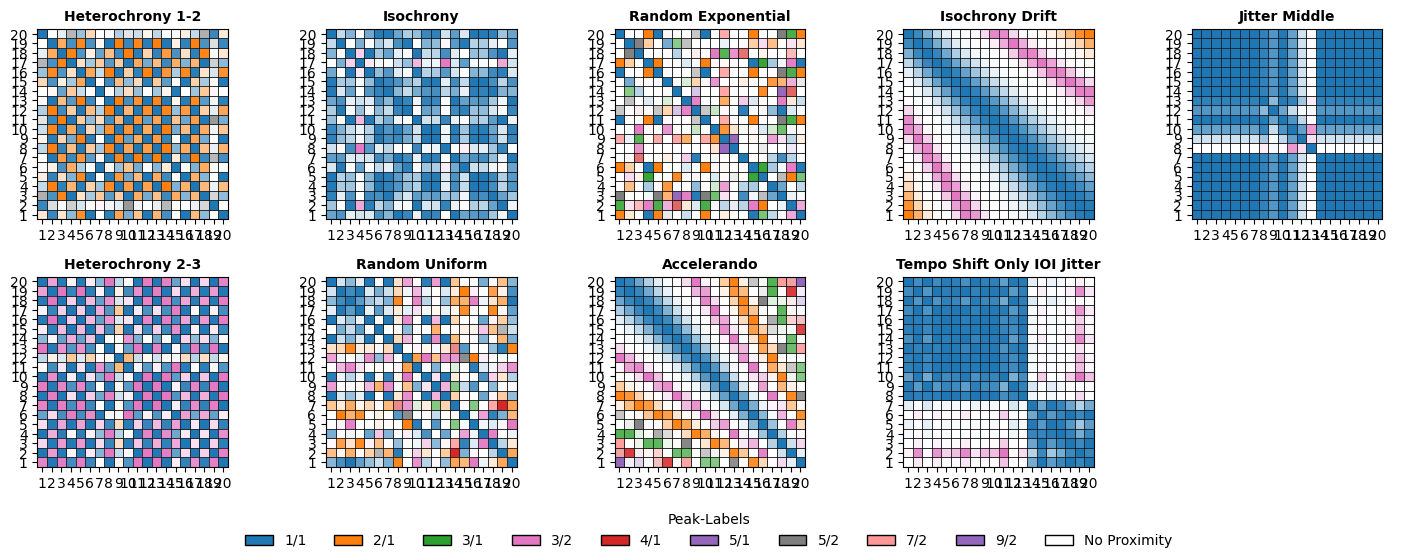

KeyboardInterrupt: 

In [ ]:
# versuuuch
from pathlib import Path
import sys
import importlib
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))

import proximitylib.proximity as prox
importlib.reload(prox)

#from proximitylib.proximity import (
#    build_pairwise_proximity_df,
#    param_sets
#)

# ============================================================
# FLEXIBLES PANEL: Reihen / Spalten + optionale Zellränder
# ============================================================
def panel_peak_matrices(
    file_dict,
    param_choice=0,
    n_rows=1,
    n_cols=None,
    figsize=(20, 10),
    draw_borders=False,
    save_path=None
):
    """
    Paperreifes Panel mit Peakvalue-Matrizen für mehrere Dateien.

    Parameters
    ----------
    file_dict : dict
        {title: path_to_csv}
    """

    n_files = len(file_dict)

    if n_cols is None:
        n_cols = math.ceil(n_files / n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = np.array(axes).reshape(-1)

    params = prox.param_sets[param_choice]

    # ------------------------------------------------
    # Farben für Peak-Labels
    # ------------------------------------------------
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2],
        "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6],
        "5/2": tab10[7], "1/3": tab10[8],
        "2/3": tab10[9], "4/3": (0.5, 0.0, 0.5)
    }

    # ------------------------------------------------
    # Alle verwendeten Peak-Labels sammeln
    # ------------------------------------------------
    all_peak_labels = set()
    for path in file_dict.values():
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = prox.build_pairwise_proximity_df(iois, params)

        labels_here = (
            pd.Series(df_pairs["peak_label"])
            .dropna()
            .astype(str)
            .unique()
        )
        labels_here = [l for l in labels_here if l.lower() != "nan" and l != ""]
        all_peak_labels.update(labels_here)

    all_peak_labels = sorted(all_peak_labels)
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")

    label_to_color = {}
    for i, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1, 1, 1)
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            label_to_color[lab] = plt.cm.tab20(i % 20)

    # ------------------------------------------------
    # Dateien plotten
    # ------------------------------------------------
    for ax, (title, path) in zip(axes, file_dict.items()):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, _, _ = prox.build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0

            y = n - i - 1  # Ursprung unten links

            ax.add_patch(
                plt.Rectangle(
                    (j, y),
                    1, 1,
                    facecolor=(*base_color[:3], alpha),
                    edgecolor="black" if draw_borders else "none",
                    linewidth=0.4 if draw_borders else 0
                )
            )

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect("equal")

        ticks = np.arange(n) + 0.5
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(np.arange(1, n + 1))
        ax.set_yticklabels(np.arange(1, n + 1))

        ax.set_title(title, fontsize=10, fontweight="bold")

    for ax in axes[n_files:]:
        ax.axis("off")

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=label_to_color[l], edgecolor="black")
        for l in all_peak_labels
    ]

    fig.legend(
        handles,
        all_peak_labels,
        loc="lower center",
        ncol=min(len(all_peak_labels), 10),
        title="Peak-Labels",
        frameon=False
    )

    fig.subplots_adjust(bottom=0.15, hspace=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Panel gespeichert unter: {save_path}")

    plt.show()


files1 = {
    "Heterochrony 1-2" : "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-1-2_jitter-0050/heterochrony-1-2_jitter-0050_04.csv",
    "Isochrony" : "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0001/isochrony_jitter-0001_04.csv",
    "Random Exponential" : "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential/random_exponential_03.csv",
    "Isochrony Drift" : "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift/isochrony_drift.csv",
    "Jitter Middle" : "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050/jitter_middle-0050_02.csv",
}

files2 = {
    "Heterochrony 2-3" : "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0050/heterochrony-2-3_jitter-0050_06.csv",
    "Isochrony" : "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0050/isochrony_jitter-0050_03.csv",
    "Random Uniform" : "../data/theoretical_sequences/baseIOI-0.50/20beats/random_uniform/random_uniform_04.csv",
    "Accelerando" : "../data/theoretical_sequences/baseIOI-0.50/20beats/accelerando/accelerando.csv",
    "Tempo Shift Only IOI Jitter" : "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050/tempo_shift_onlyioi-jitter-0050_06.csv"
}

files = {
    "Heterochrony 1-2" : "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-1-2_jitter-0050/heterochrony-1-2_jitter-0050_04.csv",
    "Isochrony" : "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0001/isochrony_jitter-0001_04.csv",
    "Random Exponential" : "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential/random_exponential_03.csv",
    "Isochrony Drift" : "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift/isochrony_drift.csv",
    "Jitter Middle" : "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050/jitter_middle-0050_02.csv",
    "Heterochrony 2-3" : "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0050/heterochrony-2-3_jitter-0050_06.csv",
    "Isochrony" : "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0050/isochrony_jitter-0050_03.csv",
    "Random Uniform" : "../data/theoretical_sequences/baseIOI-0.50/20beats/random_uniform/random_uniform_04.csv",
    "Accelerando" : "../data/theoretical_sequences/baseIOI-0.50/20beats/accelerando/accelerando.csv",
    "Tempo Shift Only IOI Jitter" : "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050/tempo_shift_onlyioi-jitter-0050_06.csv"
}

animals = {
    "Seba's short-tailed bat (Carollia perspicillata) 1" : "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p4_b4.csv",
    "Seba's short-tailed bat (Carollia perspicillata) 2" : "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p4_b9.csv",
    "Seba's short-tailed bat (Carollia perspicillata) 3" : "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p2_b7.csv",
    "Seba's short-tailed bat (Carollia perspicillata) 4" : "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p3_b2.csv",
    "Seba's short-tailed bat (Carollia perspicillata) 5" : "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p1_b3.csv",
    "Kwa-Sounds (Scorpaena spp.) 1" : "../data/Kwa-Sounds (Scorpaena spp.)/KWA2-C.csv",
    "Kwa-Sounds (Scorpaena spp.) 2" : "../data/Kwa-Sounds (Scorpaena spp.)/KWA4.csv",
    "Kwa-Sounds (Scorpaena spp.) 3" : "../data/Kwa-Sounds (Scorpaena spp.)/KWA6.csv",
    "Kwa-Sounds (Scorpaena spp.) 4" : "../data/Kwa-Sounds (Scorpaena spp.)/KWA8.csv",
    "Kwa-Sounds (Scorpaena spp.) 5" : "../data/Kwa-Sounds (Scorpaena spp.)/KWA10.csv",
    "Sperm whale (Physeter macrocephalus) 1" : "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_02.xls.csv",
    "Sperm whale (Physeter macrocephalus) 2" : "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_10.xls.csv",
    "Sperm whale (Physeter macrocephalus) 3" : "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_32.xls.csv",
    "Sperm whale (Physeter macrocephalus) 4" : "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_51.xls.csv",
    "Sperm whale (Physeter macrocephalus) 5" : "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_55.xls.csv"
}

panel_peak_matrices(
    files1,
    param_choice=3,
    n_rows=1,
    n_cols=5,
    figsize=(18, 4),
    draw_borders=True
)

panel_peak_matrices(
    files2,
    param_choice=3,
    n_rows=1,
    n_cols=5,
    figsize=(18, 4),
    draw_borders=True
)

panel_peak_matrices(
    files,
    param_choice=3,
    n_rows=2,
    n_cols=5,
    figsize=(18, 6),
    draw_borders=True
)

panel_peak_matrices(
    animals,
    param_choice=3,
    n_rows=3,
    n_cols=5,
    figsize=(20, 12),
    draw_borders=False,
    save_path="animals_panel.png"
)

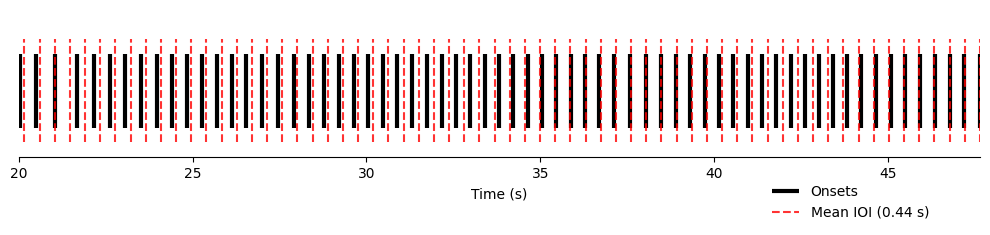

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) CSV laden
# =========================

path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_53.xls.csv"  # Pfad anpassen
filename = path.split("/")[-1].replace(".xls.csv", "")
df = pd.read_csv(path)
onsets = df["onset"].values
iois = df["IOI"].dropna().values

# =========================
# 2) Mean IOI ("perfekter Beat")
# =========================
mean_ioi = np.mean(iois)

t_start = onsets.min()
t_end = onsets.max()

perfect_beats = np.arange(t_start, t_end + mean_ioi, mean_ioi)

# =========================
# 3) Plot
# =========================
fig, ax = plt.subplots(figsize=(10, 2.5))

# reale Onsets (schwarz) – flach
ax.vlines(
    onsets,
    ymin=0.20,
    ymax=0.70,
    color="black",
    linewidth=3,
    label="Onsets"
)

# perfekter Beat (rot) – etwas höher, aber nicht bis oben
ax.vlines(
    perfect_beats,
    ymin=0.10,
    ymax=0.80,
    color="red",
    linewidth=1.5,
    alpha=0.8,
    linestyle="--",
    label=f"Mean IOI ({mean_ioi:.2f} s)"
)

# =========================
# 4) Paper-Style
# =========================
ax.set_ylim(0, 1)
ax.set_xlim(20, t_end)
ax.set_xlabel("Time (s)")
ax.set_yticks([])

for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

# Legende bewusst oben, mit Luft
ax.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(0.96, -0.1)
)

plt.tight_layout()
plt.show()
